Goal: renalysis of haircut-seq paper
Tools: mainly `scanpy`

In [ ]:
from utils import *

In [303]:
from IPython.display import Image
from IPython.core.display import HTML 
Image(url= "http://falexwolf.de/img/scanpy/anndata.svg", width = 500)

In [2]:
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor='white')

sc.logging.print_header()

scanpy==1.7.1 anndata==0.7.5 umap==0.5.1 numpy==1.19.2 scipy==1.5.3 pandas==1.1.3 scikit-learn==0.24.1 statsmodels==0.12.2 python-igraph==0.8.3 leidenalg==0.8.3


# Load raw count files 
Here we aim to load `kb-count` results into python using `scanpy` library. 

### mix15 experiment

In [205]:
mix15_m, mix15_r = read_data('mix15')

Trying to set attribute `.var` of view, copying.
Trying to set attribute `.obs` of view, copying.


In [283]:
# create a dictionary to map cluster to annotation label
cluster2annotation = {
     '0': 'One','4': 'One','6': 'One',
     '1': 'Two','2': 'Two','3': 'Two','5': 'Two'
}

# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
mix15_m.obs['repair'] = mix15_r.obs['clusters'].map(cluster2annotation).astype('category')
mix15_r.obs['repair'] = mix15_r.obs['clusters'].map(cluster2annotation).astype('category')

... storing 'gene_name' as categorical
... storing 'mt' as categorical


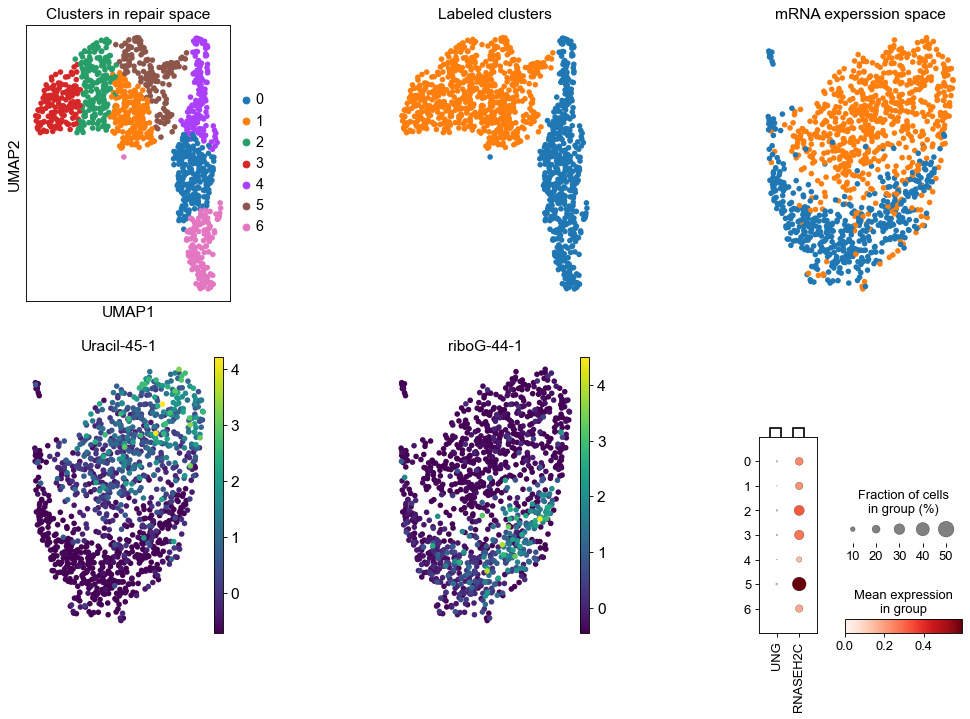

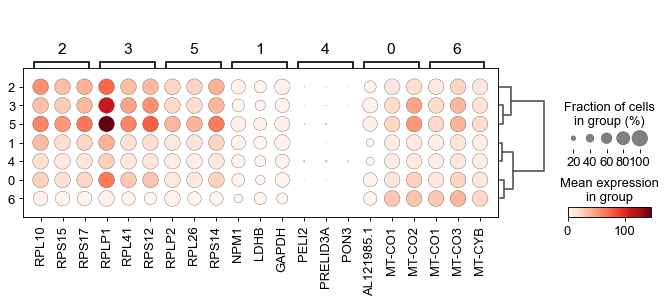

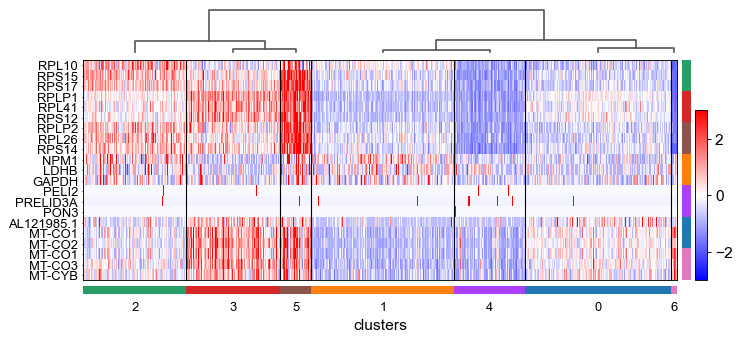

In [297]:
plot_expriment(mix15_m,mix15_r)
plot_rank_genes_heatmap(mix15_m)

### mix30 experiment

In [291]:
mix30_m,mix30_r = read_data('mix30')

Trying to set attribute `.var` of view, copying.
Trying to set attribute `.obs` of view, copying.


In [292]:
# create a dictionary to map cluster to annotation label
cluster2annotation = {
     '0': 'One','4': 'One','6': 'One','2': 'One',
     '1': 'Two','3': 'Two','5': 'Two'
}

# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
mix30_m.obs['repair'] = mix30_r.obs['clusters'].map(cluster2annotation).astype('category')
mix30_r.obs['repair'] = mix30_r.obs['clusters'].map(cluster2annotation).astype('category')

... storing 'gene_name' as categorical
... storing 'mt' as categorical


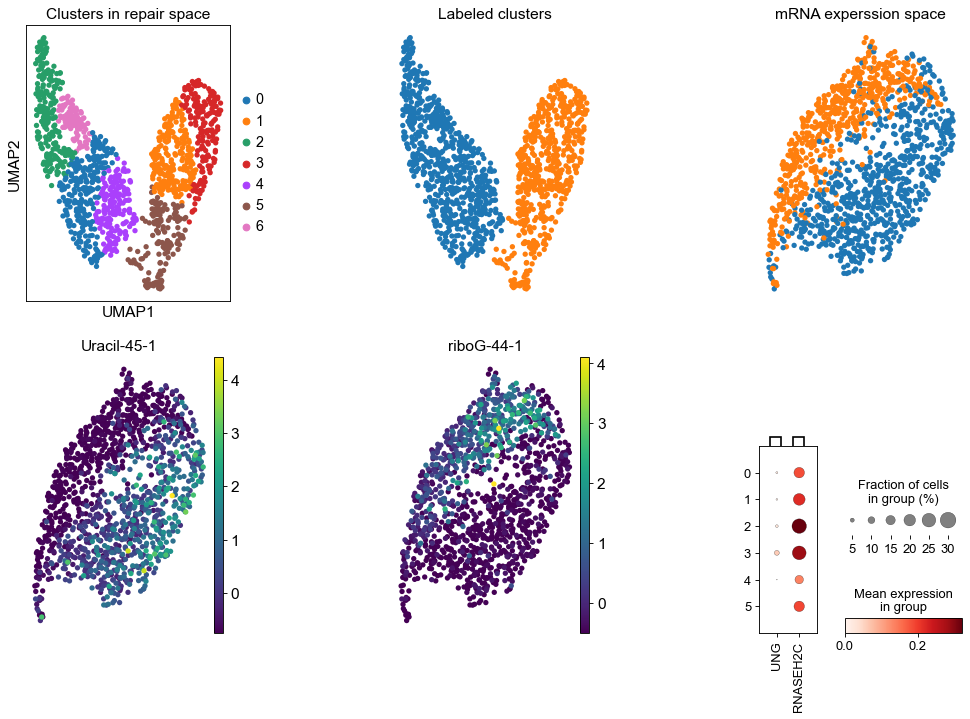

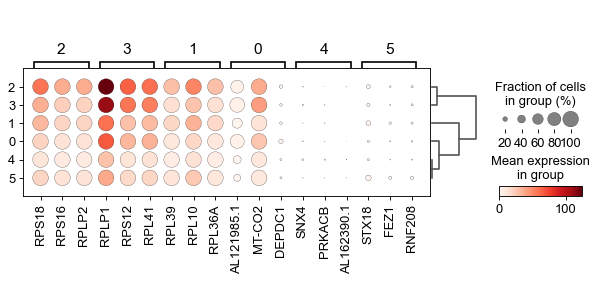

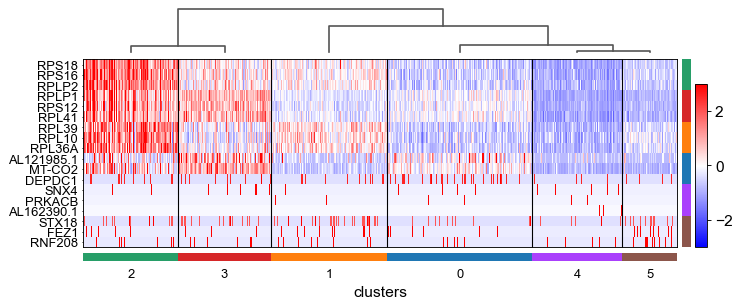

In [296]:
plot_expriment(mix30_m,mix30_r)
plot_rank_genes_heatmap(mix30_m)

### mix60 experiment

In [299]:
mix60_m,mix60_r = read_data('mix60')

Trying to set attribute `.var` of view, copying.
Trying to set attribute `.obs` of view, copying.


In [300]:
# create a dictionary to map cluster to annotation label
cluster2annotation = {
     '0': 'One','4': 'One','6': 'One','2': 'One',
     '1': 'Two','3': 'Two','5': 'Two','7': 'Two'
}

# add a new `.obs` column called `cell type` by mapping clusters to annotation using pandas `map` function
mix60_m.obs['repair'] = mix60_r.obs['clusters'].map(cluster2annotation).astype('category')
mix60_r.obs['repair'] = mix60_r.obs['clusters'].map(cluster2annotation).astype('category')

... storing 'gene_name' as categorical
... storing 'mt' as categorical


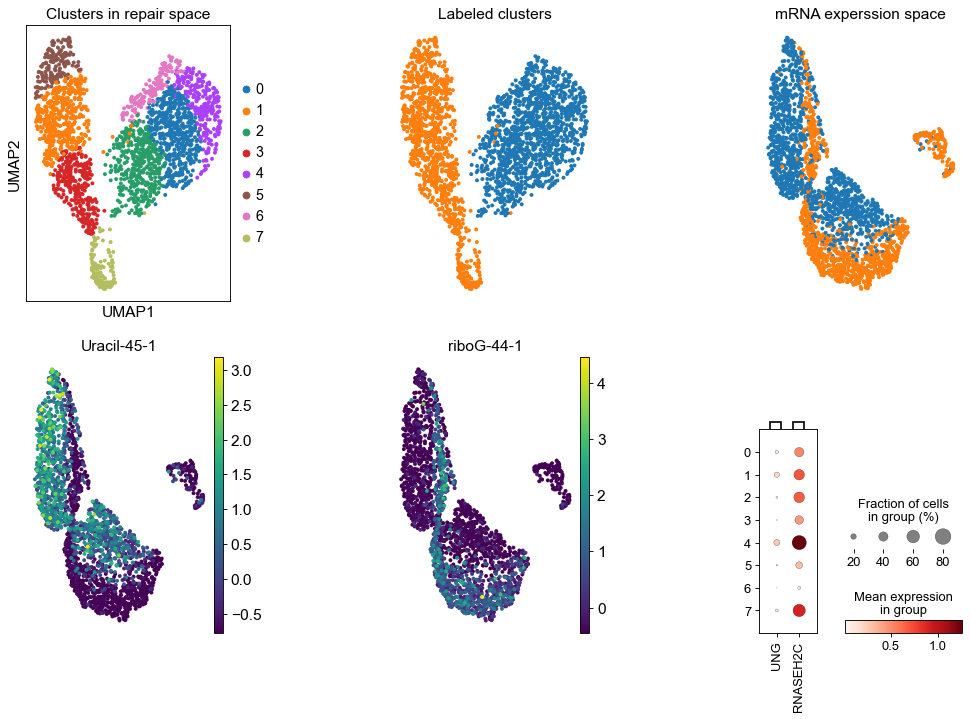

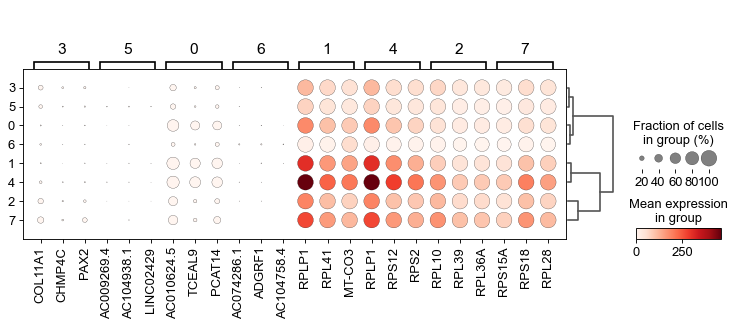

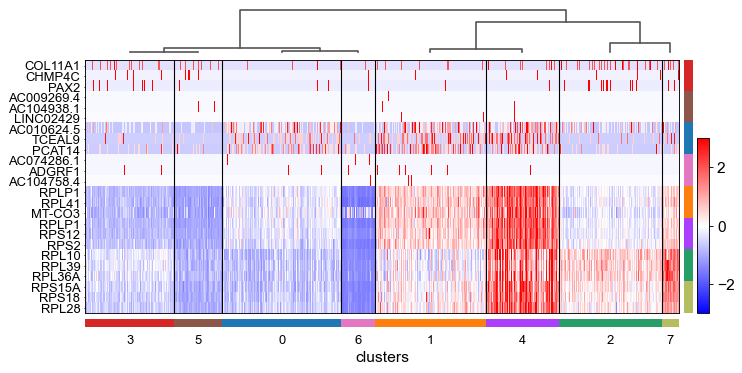

In [301]:
plot_expriment(mix60_m,mix60_r)
plot_rank_genes_heatmap(mix60_m)

## Highest expresed genes

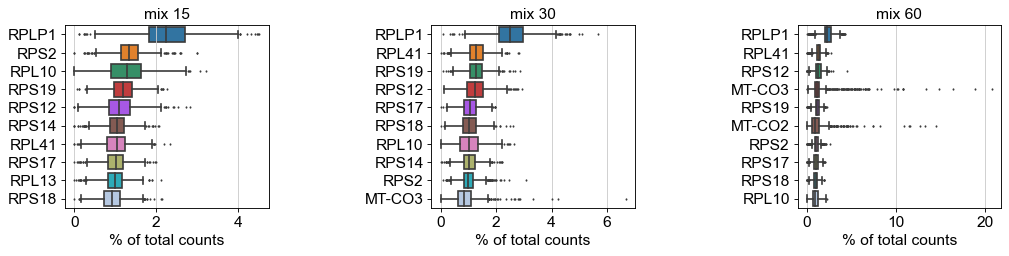

In [206]:
fig, axes = plt.subplots(1, 3, figsize=(15,3), gridspec_kw={'wspace':0.8})
ax1_dict = sc.pl.highest_expr_genes(mix15, n_top=10,ax=axes[0],show=False)
ax1_dict.set_title('mix 15')
ax2_dict = sc.pl.highest_expr_genes(mix30, n_top=10,ax=axes[1],show=False)
ax2_dict.set_title('mix 30')
ax3_dict = sc.pl.highest_expr_genes(mix60, n_top=10,ax=axes[2],show=False)
ax3_dict.set_title('mix 60')

plt.show()

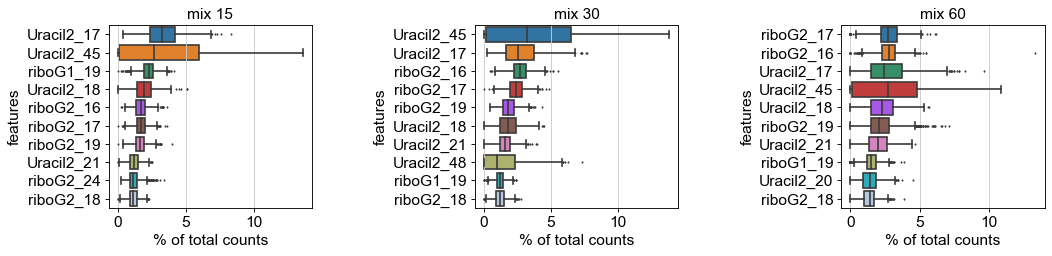

In [219]:
fig, axes = plt.subplots(1, 3, figsize=(15,3), gridspec_kw={'wspace':0.8})
ax1_dict = sc.pl.highest_expr_genes(mix15_r, n_top=10,ax=axes[0],show=False)
ax1_dict.set_title('mix 15')
ax2_dict = sc.pl.highest_expr_genes(mix30_r, n_top=10,ax=axes[1],show=False)
ax2_dict.set_title('mix 30')
ax3_dict = sc.pl.highest_expr_genes(mix60_r, n_top=10,ax=axes[2],show=False)
ax3_dict.set_title('mix 60')

plt.show()

# Merge all data 

In [384]:
# mRNA experssion 
mix_m = mix15_m.concatenate(mix30_m,mix60_m).to_df()
mix_m = ad.AnnData(mix_m)
mix_m.obs['time'] = 0
mix_m.obs.loc[mix_m.obs.index.str.contains('-0'),'time'] = 15
mix_m.obs.loc[mix_m.obs.index.str.contains('-1'),'time'] = 30
mix_m.obs.loc[mix_m.obs.index.str.contains('-2'),'time'] = 60

# hairpin counts 
mix_r = mix15_r.concatenate(mix30_r,mix60_r).to_df()
mix_r = ad.AnnData(mix_r)
mix_r.obs['time'] = 0
mix_r.obs.loc[mix_r.obs.index.str.contains('-0'),'time'] = 15
mix_r.obs.loc[mix_r.obs.index.str.contains('-1'),'time'] = 30
mix_r.obs.loc[mix_r.obs.index.str.contains('-2'),'time'] = 60


___


### Save processed data 
Here, we write objects contain preprocessed and clustered data into files. Then, we remove that from the RAM. 

In [385]:
mix_m.write('reanalyzed-data/mix-mRNA-experssion.h5ad')
mix_r.write('reanalyzed-data/mix-repair-phenotype.h5ad')

In [18]:
# write_adata(mix15,'reanalyzed-data/mix15')

In [17]:
# from zipfile import ZipFile
# # https://thispointer.com/python-how-to-create-a-zip-archive-from-multiple-files-or-directory/
# def write_adata(adata,name):
#     adata.obs.to_csv(f'{name}.mtx_rows')
#     adata.var.to_csv(f'{name}.mtx_cols')
#     adata.to_df().to_csv(f'{name}.mtx')

#     # create a ZipFile object
#     zipObj = ZipFile(f'{name}.zip', 'w')
#     # Add multiple files to the zip
#     zipObj.write(f'{name}.mtx_rows')
#     zipObj.write(f'{name}.mtx_cols')
#     zipObj.write(f'{name}.mtx')
#     # close the Zip File
#     zipObj.close()

A zip, tar.gz, tgz, or gzip file of the three MatrixMarket files (.mtx, .mtx_cols, .mtx_rows)